# Earthquake effect on house prices

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

from read_cbs_data import *

## DAG

S = Seismic activities (or earthquakes)
R = Risk of future earthquakes (binary if it is in groningen)
y = house prices

At least S -> R -> Y 

Confounder? I think it is difficult to assume it affects Y directly, so I think no confounding

L = Location characteristics (fault zones)



## Reading in data

In [13]:
gdf_gemeenten = concatenate_cbs_gebieden(list(range(1995, 2026)), "gemeente_gegeneraliseerd")
gdf_provincies = concatenate_cbs_gebieden(list(range(1995, 2026)), "provincie_gegeneraliseerd")

gdf_joined = join_gemeente_with_provincie(gdf_gemeenten, gdf_provincies)

# Manually filling in the missing province for Voerendaal
gdf_joined.loc[gdf_joined['provincie'].isna(), 'provincie'] = 'Limburg'

# Adjust province name for consistency
gdf_joined['provincie'] = gdf_joined['provincie'].replace({'Fryslân': 'Friesland'})

df_prijsindex = read_prijsindex_data()
gdf_area_prijs = gdf_joined.merge(df_prijsindex, on=['gemeente', 'jaar'], how='inner')
gdf_aardbevingen = transform_aardbevingen_data(filter_aardbevingen_data(read_aardbevingen_data()))

In [14]:
gdf_area_prijs

,gemeente,geometry,jaar,provincie,kwartaal,price_index
0,Almere,"MULTIPOLYGON (((143040.703 482792.406, 143123....",1995,Flevoland,1,31.3
1,Almere,"MULTIPOLYGON (((143040.703 482792.406, 143123....",1995,Flevoland,2,31.7
2,Almere,"MULTIPOLYGON (((143040.703 482792.406, 143123....",1995,Flevoland,3,31.7
3,Almere,"MULTIPOLYGON (((143040.703 482792.406, 143123....",1995,Flevoland,4,32.2
4,Stadskanaal,"MULTIPOLYGON (((261909.094 562849.625, 260265....",1995,Groningen,1,32.1
...,...,...,...,...,...,...
33722,Maashorst,"MULTIPOLYGON (((176672.671 418565.125, 176593....",2025,Noord-Brabant,2,149.2
33723,Maashorst,"MULTIPOLYGON (((176672.671 418565.125, 176593....",2025,Noord-Brabant,3,152.7
33724,Voorne aan Zee,"MULTIPOLYGON (((74542.72 426994.31, 74522.85 4...",2025,Zuid-Holland,1,146.3
33725,Voorne aan Zee,"MULTIPOLYGON (((74542.72 426994.31, 74522.85 4...",2025,Zuid-Holland,2,148.5


In [15]:
t = gdf_area_prijs.value_counts(['gemeente', 'jaar']).reset_index(name='count').query('count <4')
print(set(t['jaar']))
# Only 2025 seems to have some missing quarters

# All the municipalities seem to have been correctly matched to each quarter, with the exception of 2025 Q4. Probably not in the original data
gdf_area_prijs[(gdf_area_prijs['jaar'] == 2025) & (gdf_area_prijs['kwartaal'] == 4)]

{2025}


,gemeente,geometry,jaar,provincie,kwartaal,price_index


## Plotting the distribution of earthquakes

- Event type is indicated by color
- Size of the circles are the magnitudes
- Results:
    - In the KNMI data there is a differentiation in the type of earthquake.
    - Groningen mostly induced events
    - Rest are (natural) earthquakes
    - Seismic events will be used in the terminology to account for these distinctions

TODO:
- Plot distribution of prices --> Log transform?
- Check parralel trends assumption

c:\Users\tayyi\anaconda3\envs\slr_env\Lib\site-packages\matplotlib\collections.py:963: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


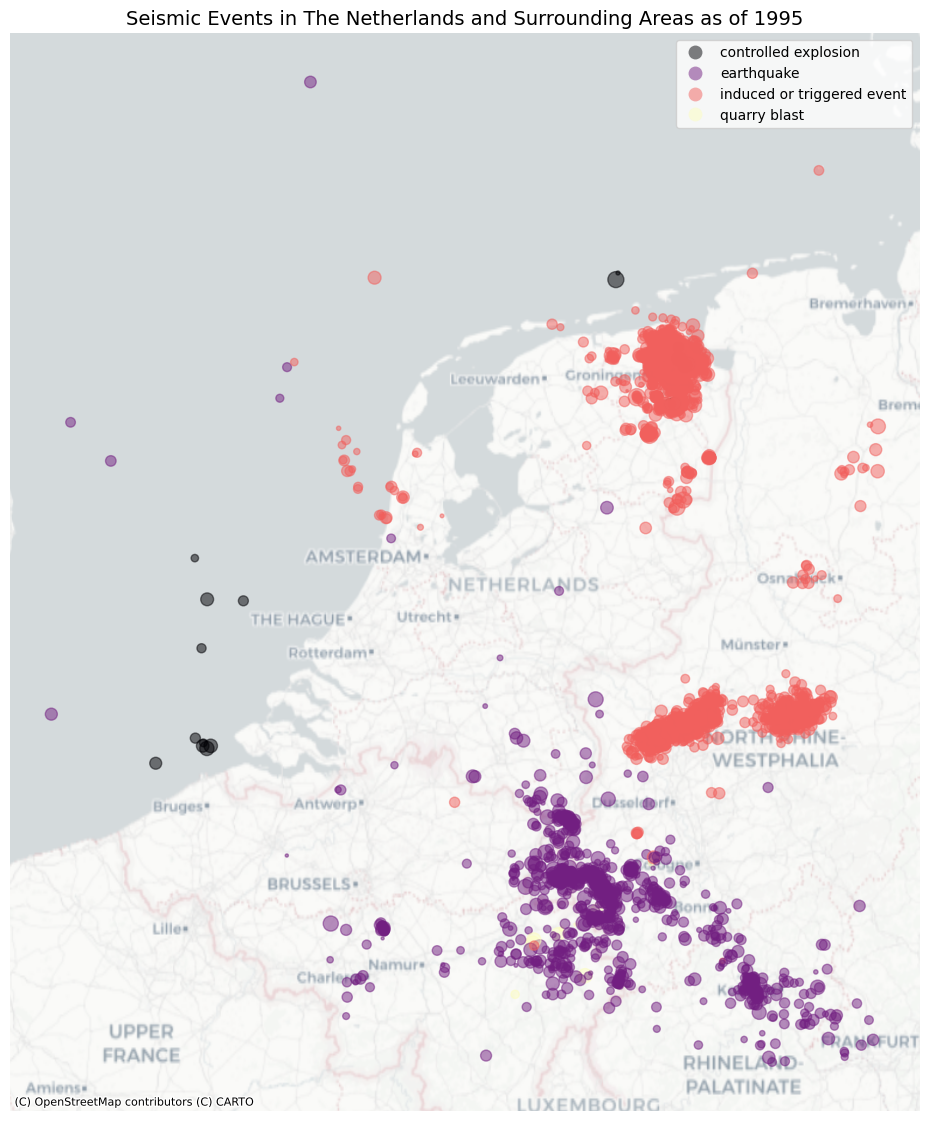

In [10]:
tmp = gdf_aardbevingen.copy()
tmp['x'] = tmp.geometry.x
tmp['y'] = tmp.geometry.y

tmp = tmp[(tmp['x'] > -5.0) & (tmp['y'] > 50)] 

ax = tmp.plot(
    column="event_type",    
    cmap="magma",
    markersize=gdf_aardbevingen["magnitude"] * 30,  
    alpha=0.5,
    legend=True,
    figsize = (14, 14)
)

ctx.add_basemap(ax, crs=gdf_aardbevingen.crs, source=ctx.providers.CartoDB.Positron)

ax.set_title("Seismic Events in The Netherlands and Surrounding Areas as of 1995", fontsize=14)
ax.set_axis_off() 

* Note: Circle size represents earthquake magnitude and does not correspond to the area affected.

array([[<Axes: title={'center': '1'}>, <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>]],
      dtype=object)

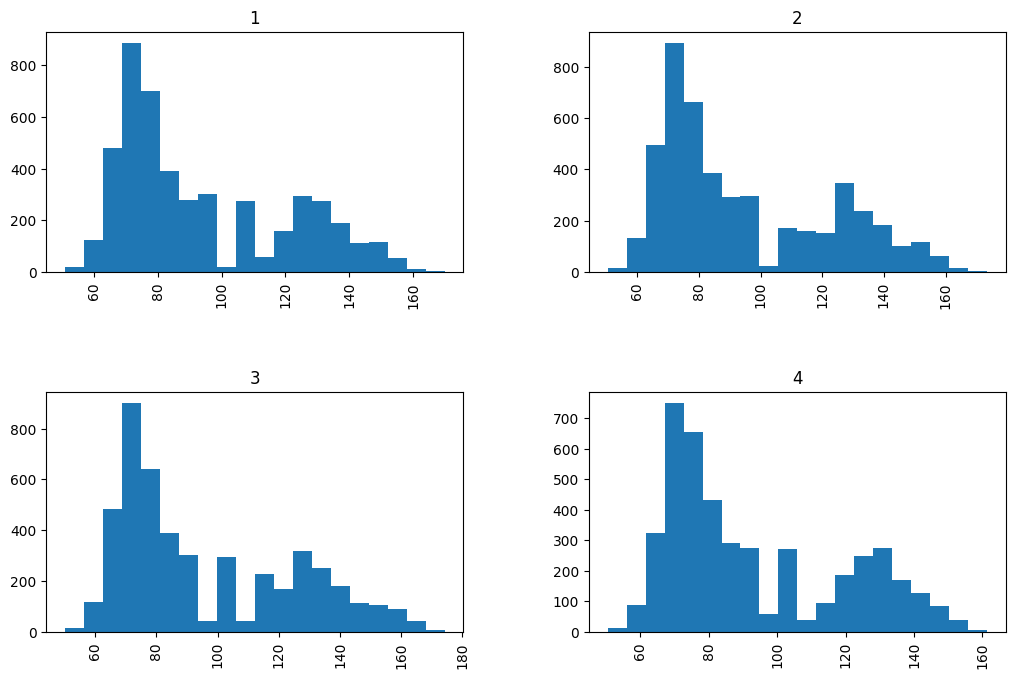

In [11]:
gdf_area_prijs['price_index'].hist(by=gdf_area_prijs['kwartaal'], bins=20, figsize=(12, 8))

## Analysis Methods

1. R: sf (https://github.com/r-spatial/sf), dplyr en fixest (https://github.com/lrberge/fixest) for distance based exposure to treatment. With potential event strudy extension. (make exposure variable)
     - common: distance from earthquake to municipality boundary (instead of centroid) using st_distance() directly with polygons.
     - Implement dynamic effects with sunab()
     - From example, looks similar to python approach below but in R and abstracted away into the packages
2. Python: PySAL. Make spatial weights using KNN? More info necessary here
3. R: just using fixest. Apparently popular and recommende by ChatGPT and the approach already handles spatial DiD designs.
    - model <- feols(
        price ~ earthquake_intensity | municipality + quarter,
        data = housing_data,
        cluster = ~ municipality
        )

        summary(model)

        municipality = spatial fixed effects

        quarter = time fixed effects

        cluster = municipality = corrects serial correlation

## Spatial join earthquake data on municipality

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from scipy.spatial import distance_matrix

# -------------------------------
# 1. Load your datasets
# -------------------------------

# Municipality polygons with yearly panel data
muni_gdf = gpd.read_file('municipalities.geojson')  # must have column 'municipality'
muni_panel = pd.read_csv('municipality_panel.csv')  # yearly data

# Earthquake points
eq_df = pd.read_csv('earthquakes.csv')  # columns: date, magnitude, latitude, longitude
eq_df['geometry'] = eq_df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
eq_gdf = gpd.GeoDataFrame(eq_df, geometry='geometry', crs=muni_gdf.crs)

# -------------------------------
# 2. Compute municipality centroids
# -------------------------------
muni_gdf['centroid'] = muni_gdf.geometry.centroid
centroids = muni_gdf['centroid'].to_list()
muni_names = muni_gdf['municipality'].to_list()
n_muni = len(centroids)

# -------------------------------
# 3. Prepare earthquakes per year
# -------------------------------
eq_gdf['year'] = pd.to_datetime(eq_gdf['date']).dt.year
years = eq_gdf['year'].unique()
n_eq = len(eq_gdf)

# -------------------------------
# 4. Compute distance matrix (municipality centroid to all earthquakes)
# -------------------------------
# Extract coordinates
muni_coords = np.array([[c.x, c.y] for c in centroids])
eq_coords = np.array([[p.x, p.y] for p in eq_gdf.geometry])

# Euclidean distance in same CRS units (adjust CRS for meters/kilometers if needed)
dist_mat = distance_matrix(muni_coords, eq_coords)  # shape: (n_muni, n_eq)

# -------------------------------
# 5. Compute distance-weighted exposure
# -------------------------------
def exposure_weight(distance_km, magnitude, decay=50):
    """Exponential decay by distance (distance in km)."""
    return magnitude * np.exp(-distance_km / decay)

# Apply exposure weighting
mag_array = eq_gdf['magnitude'].values.reshape(1, -1)  # shape (1, n_eq)
exposure_mat = exposure_weight(dist_mat, mag_array)     # shape (n_muni, n_eq)

# -------------------------------
# 6. Aggregate exposure per municipality per year
# -------------------------------
muni_year_exposure = []

for i, muni in enumerate(muni_names):
    for year in years:
        mask = eq_gdf['year'].values == year
        yearly_exposure = exposure_mat[i, mask].sum()
        muni_year_exposure.append({
            'municipality': muni,
            'year': year,
            'distance_to_earthquake': yearly_exposure
        })

muni_year_df = pd.DataFrame(muni_year_exposure)

# -------------------------------
# 7. Merge with municipality panel data
# -------------------------------
panel_data = muni_panel.merge(muni_year_df, on=['municipality','year'], how='left')
panel_data['distance_to_earthquake'] = panel_data['distance_to_earthquake'].fillna(0)

# -------------------------------
# 8. OPTIONAL: compute spatial lag (neighbors) for spillovers
# -------------------------------
# Simple inverse distance weights (row-standardized)
inv_dist = 1 / np.where(dist_mat == 0, np.nan, dist_mat)
np.fill_diagonal(inv_dist, 0)
W = inv_dist / inv_dist.sum(axis=1, keepdims=True)

panel_data['lag_distance_to_earthquake'] = 0
for y in years:
    year_data = panel_data[panel_data['year'] == y]
    dist_vector = year_data['distance_to_earthquake'].values
    lag_vector = W @ dist_vector
    panel_data.loc[panel_data['year'] == y, 'lag_distance_to_earthquake'] = lag_vector

# -------------------------------
# 9. Set panel index for DiD / causal ML
# -------------------------------
panel_data = panel_data.set_index(['municipality','year'])

# -------------------------------
# 10. Ready for regression
# -------------------------------
print(panel_data.head())


## First standard panel DiD

For municapilty fixed effects and time FE

In [ ]:
import pandas as pd
from linearmodels.panel import PanelOLS

# Load your panel dataset
df = pd.read_csv('housing_earthquake_panel.csv')

# Set multi-index for panel (municipality × time)
df = df.set_index(['municipality', 'time'])

# Optional: demean continuous controls if you want (or include as covariates)
# Here we include gem_vermogen as a pre-treatment control
exog_vars = ['distance_to_earthquake', 'gem_vermogen']
exog = df[exog_vars]
exog = sm.add_constant(exog)

# Outcome variable
y = df['prijsindex_houses']

# Fit panel fixed effects model (municipality and time FE)
mod = PanelOLS(y, exog, entity_effects=True, time_effects=True)
res = mod.fit(cov_type='clustered', cluster_entity=True)

print(res.summary)

## Spatial panel DiD


Distance-weighted exposure of neighboring municipalities

Include spatial lag of treatment (W D_{it}) for spillovers

Optionally include spatial lag of outcome (W P_{it}) if housing markets are highly correlated

In [ ]:
import numpy as np
import libpysal
from scipy.spatial import distance_matrix

# Create coordinates array (municipality centroids)
coords = df.reset_index().drop_duplicates('municipality')[['x_coord','y_coord']].values

# Compute pairwise Euclidean distances
dist_mat = distance_matrix(coords, coords)

# Inverse distance weighting (replace zeros on diagonal to avoid division by zero)
inv_dist = 1 / np.where(dist_mat==0, np.nan, dist_mat)
np.fill_diagonal(inv_dist, 0)  # no self-weight

# Row-standardize the weights matrix
W = inv_dist / inv_dist.sum(axis=1, keepdims=True)

# Map municipality names to row indices
muni_names = df.reset_index()['municipality'].unique()
muni_map = {name: i for i, name in enumerate(muni_names)}

# Create spatially lagged treatment
df_reset = df.reset_index()
df_reset['lag_distance_to_earthquake'] = df_reset.apply(
    lambda row: np.dot(W[muni_map[row['municipality']], :], 
                       df_reset[df_reset['time']==row['time']]['distance_to_earthquake'].values),
    axis=1
)

# Re-set index
df_spatial = df_reset.set_index(['municipality','time'])

# Exogenous variables now include direct + spatial lag
exog_vars = ['distance_to_earthquake', 'lag_distance_to_earthquake', 'gem_vermogen']
exog = sm.add_constant(df_spatial[exog_vars])
y = df_spatial['prijsindex_houses']

# Fit PanelOLS with FE
mod_spatial = PanelOLS(y, exog, entity_effects=True, time_effects=True)
res_spatial = mod_spatial.fit(cov_type='clustered', cluster_entity=True)

print(res_spatial.summary)